In [2]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import lqr_utils_seq as lqr
from functools import partial
from datasets import load_dataset
import random
import pickle
import time
from steering import LQRSteering
from data_handling import ContrastiveBuilder
import yaml
import random
import json
from linearization import compute_lin_err as OLcompute_lin_err
import matplotlib.pyplot as plt
import numpy as np
import tox_data_script as utils


/home/jskifstad/labcode/ctrlgpt/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [6]:
with open('config/config.yaml', 'r') as f:
    config_data = yaml.safe_load(f)
PICKLE_JAR = config_data["environment"]["pickle_jar"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")


def load_model(model_name, quant=False):

    if quant:
        quant_config = BitsAndBytesConfig(
            load_in_4bit=True,          # or load_in_8bit=True
            # load_in_8bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type="nf4",  # best for LLMs
            bnb_4bit_use_double_quant=True,
        )
        model = AutoModelForCausalLM.from_pretrained(
            model_name, quantization_config=quant_config, dtype=torch.float32, device_map="auto")
        tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    else: 
        model = AutoModelForCausalLM.from_pretrained(
            model_name).to(device)
        tokenizer = AutoTokenizer.from_pretrained(model_name)

    return model, tokenizer
        

def get_safe_prompts():
    dataset = load_dataset("tatsu-lab/alpaca")
    return dataset['train'][:]["instruction"]

def load_file(filename):
    try:
        with open(PICKLE_JAR + filename + ".pkl", "rb") as f:
            return pickle.load(f)
    except FileNotFoundError:
        return None

device: cuda


In [7]:
model_name = "google/gemma-2-2b"
# model_name = "Qwen/Qwen2.5-3B"
# model_name = "meta-llama/Meta-Llama-3-8B"

# model_name = "google/gemma-2-9b-it"
# model_name = "Qwen/Qwen2.5-14B-Instruct"


model, tokenizer = load_model(model_name, quant=True)

dataguy = ContrastiveBuilder(model, tokenizer)
toxic_prompts = utils.get_tox_prompts(0.8, 0.9)

acts, As = dataguy.collect_acts_and_jacs(prompts=toxic_prompts, num_samples=10, filename="qwen-acts-jacs")

print(As.shape)






Loading checkpoint shards: 100%|██████████| 3/3 [00:06<00:00,  2.01s/it]


model device: cuda:0
Latent dim: 2304
iter: 1
torch.Size([27, 11, 2304])
iter: 2
torch.Size([27, 27, 2304])
iter: 3
torch.Size([27, 12, 2304])
iter: 4
torch.Size([27, 15, 2304])
iter: 5
torch.Size([27, 10, 2304])
iter: 6
torch.Size([27, 13, 2304])
iter: 7
torch.Size([27, 24, 2304])
iter: 8
torch.Size([27, 13, 2304])
iter: 9
torch.Size([27, 20, 2304])
iter: 10
torch.Size([27, 10, 2304])
torch.Size([10, 26, 2304, 2304])


layer: 0
angles 0: 0.7285248041152954
angles 1: 0.7540537714958191
angles 2: 0.8071857690811157



KeyboardInterrupt: 

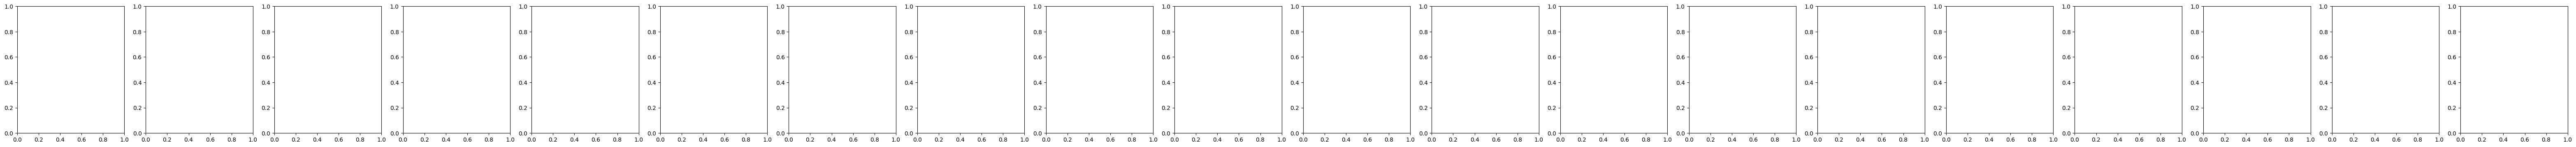

In [8]:
num_layers = 20  # how many layers you want to plot

fig, axes = plt.subplots(1, num_layers, figsize=(4*num_layers, 4))  # 1 row, num_layers columns
from scipy.linalg import subspace_angles
k=150
for i in range(0, num_layers):
    A_np = As[0][i].detach().cpu().numpy()
    B_np = As[1][i].detach().cpu().numpy()
    C_np = As[2][i].detach().cpu().numpy()

    U0 = np.linalg.svd(A_np, full_matrices=False)[0][:, :k]
    U1 = np.linalg.svd(B_np, full_matrices=False)[0][:, :k]
    U2 = np.linalg.svd(C_np, full_matrices=False)[0][:, :k]

    angles = subspace_angles(U0, U1)
    angles1 = subspace_angles(U2, U1)
    angles2 = subspace_angles(U0, U2)


    # n=10
    # print(f"angles 0: {np.mean(np.cos(angles))}")
    # print(f"angles 1: {np.mean(np.cos(angles1))}")
    # print(f"angles 2: {np.mean(np.cos(angles2))}")
# 
    n=10
    print(f"layer: {i}")
    print(f"angles 0: {np.mean(np.cos(np.partition(angles,n)[:n]))}")
    print(f"angles 1: {np.mean(np.cos(np.partition(angles1,n)[:n]))}")
    print(f"angles 2: {np.mean(np.cos(np.partition(angles2,n)[:n]))}\n")

    # Compute singular values
    sA = np.linalg.svd(A_np, compute_uv=False)
    sB = np.linalg.svd(B_np, compute_uv=False)
    sC = np.linalg.svd(C_np, compute_uv=False)
    max_s = max(sA.max(), sB.max(), sC.max())

    ax = axes[i-10]  # current subplot
    ax.semilogy(sA / max_s, label="0")
    ax.semilogy(sB / max_s, label="1")
    ax.semilogy(sC / max_s, label="2")
    ax.set_title(f"Layer {i}")
    ax.set_xlabel("Mode index")
    ax.set_ylabel("Normalized singular value")
    ax.legend()


plt.tight_layout()
plt.savefig("qwen-layer-0-semilogy.png")
plt.show()

In [ ]:
# import numpy as np
# from scipy.linalg import subspace_angles

# As: list of 3 lists of PyTorch tensors, one per trajectory/set
# num_layers: number of layers
# Define search ranges

num_layers = 5

k_range = range(5, 201, 5)  # singular vectors to consider
n_range = range(10, 50, 10)     # number of smallest angles to average

best_score = -np.inf
best_params = None

# Iterate over layers
for i in range(num_layers):
    print(f"Layer {i}")
    
    A_np = As[0][i].detach().cpu().numpy()
    B_np = As[1][i].detach().cpu().numpy()
    C_np = As[2][i].detach().cpu().numpy()
    
    # Precompute full SVD for speed
    U0_full = np.linalg.svd(A_np, full_matrices=False)[0]
    U1_full = np.linalg.svd(B_np, full_matrices=False)[0]
    U2_full = np.linalg.svd(C_np, full_matrices=False)[0]

    layer_best_score = -np.inf
    layer_best_params = None

    # Sweep over k and n
    for k in k_range:
        if k > U0_full.shape[1] or k > U1_full.shape[1] or k > U2_full.shape[1]:
            continue  # skip if k too large for this layer

        U0 = U0_full[:, :k]
        U1 = U1_full[:, :k]
        U2 = U2_full[:, :k]

        angles_01 = subspace_angles(U0, U1)
        angles_12 = subspace_angles(U1, U2)
        angles_02 = subspace_angles(U0, U2)

        for n in n_range:
            if n >= k:
                continue  # can't take more angles than vectors

            score = (
                np.mean(np.cos(np.partition(angles_01, n)[:n])) +
                np.mean(np.cos(np.partition(angles_12, n)[:n])) +
                np.mean(np.cos(np.partition(angles_02, n)[:n]))
            ) / 3  # average across pairs

            # maximize score; break ties by larger k, then larger n
            if score > layer_best_score or (score == layer_best_score and (k, n) > layer_best_params):
                layer_best_score = score
                layer_best_params = (k, n)

    best_score = max(best_score, layer_best_score)
    print(f"Best score for layer {i}: {layer_best_score:.4f} at k={layer_best_params[0]}, n={layer_best_params[1]}\n")


Layer 0
Best score for layer 0: 0.8427 at k=200, n=1

Layer 1


KeyboardInterrupt: 

In [11]:
# import numpy as np
# from scipy.linalg import subspace_angles

# As: list of 3 lists of PyTorch tensors, one per trajectory/set
# num_layers: number of layers
# Set k = max number of singular vectors to consider (top modes)
k_max = 200

for i in range(num_layers):
    print(f"Layer {i}")
    
    # Convert tensors to numpy
    A_np = As[0][i].detach().cpu().numpy()
    B_np = As[1][i].detach().cpu().numpy()
    C_np = As[2][i].detach().cpu().numpy()

    A_m = (A_np + B_np + C_np) / 3

    # Full SVD
    UA, sA, _ = np.linalg.svd(A_np, full_matrices=False)
    UB, sB, _ = np.linalg.svd(B_np, full_matrices=False)
    UC, sC, _ = np.linalg.svd(C_np, full_matrices=False)
    UAm, sAm, _ = np.linalg.svd(A_m, full_matrices=False)

    # Keep top k modes
    k = min(k_max, UA.shape[1], UB.shape[1], UC.shape[1], UAm.shape[1])
    UA = UA[:, :k]
    UB = UB[:, :k]
    UC = UC[:, :k]
    UAm = UAm[:, :k]

    sA = sA[:k]
    sB = sB[:k]
    sC = sC[:k]
    sAm = sAm[:k]

    # Compute subspace angles
    angles_01 = subspace_angles(UA, UB)
    angles_12 = subspace_angles(UB, UC)
    angles_02 = subspace_angles(UA, UC)
    
    angles_m0 = subspace_angles(UAm, UA)
    angles_m1 = subspace_angles(UAm, UB)
    angles_m2 = subspace_angles(UAm, UC)

    # Energy-weighted cosine similarity
    # Normalize singular values to sum=1 to get relative energy
    wA = sA / sA.sum()
    wB = sB / sB.sum()
    wC = sC / sC.sum()
    wAm = sAm / sAm.sum()

    def weighted_cos(angles, wX, wY):
        # Take average of cosines weighted by geometric mean of mode energies
        # Use min length in case kX != kY
        k = min(len(wX), len(wY), len(angles))
        weights = np.sqrt(wX[:k] * wY[:k])
        return np.sum(weights * np.cos(angles[:k])) / np.sum(weights)

    score_01 = weighted_cos(angles_01, wA, wB)
    score_12 = weighted_cos(angles_12, wB, wC)
    score_02 = weighted_cos(angles_02, wA, wC)
    
    score_m0 = weighted_cos(angles_m0, wAm, wA)
    score_m1 = weighted_cos(angles_m1, wAm, wB)
    score_m2 = weighted_cos(angles_m2, wAm, wC)

    print(f"Energy-weighted similarity (0-1): {score_01:.4f}")
    print(f"Energy-weighted similarity (1-2): {score_12:.4f}")
    print(f"Energy-weighted similarity (0-2): {score_02:.4f}\n")

    print(f"Energy-weighted similarity (m-0): {score_m0:.4f}")
    print(f"Energy-weighted similarity (m-1): {score_m1:.4f}")
    print(f"Energy-weighted similarity (m-2): {score_m2:.4f}\n")


Layer 0
Energy-weighted similarity (0-1): 0.2803
Energy-weighted similarity (1-2): 0.2986
Energy-weighted similarity (0-2): 0.3536

Energy-weighted similarity (m-0): 0.5596
Energy-weighted similarity (m-1): 0.6767
Energy-weighted similarity (m-2): 0.4620

Layer 1
Energy-weighted similarity (0-1): 0.2859
Energy-weighted similarity (1-2): 0.2640
Energy-weighted similarity (0-2): 0.3257

Energy-weighted similarity (m-0): 0.5115
Energy-weighted similarity (m-1): 0.6324
Energy-weighted similarity (m-2): 0.4896

Layer 2
Energy-weighted similarity (0-1): 0.2483
Energy-weighted similarity (1-2): 0.2311
Energy-weighted similarity (0-2): 0.3151

Energy-weighted similarity (m-0): 0.4982
Energy-weighted similarity (m-1): 0.6206
Energy-weighted similarity (m-2): 0.4685

Layer 3
Energy-weighted similarity (0-1): 0.2437
Energy-weighted similarity (1-2): 0.2285
Energy-weighted similarity (0-2): 0.2506

Energy-weighted similarity (m-0): 0.4089
Energy-weighted similarity (m-1): 0.7270
Energy-weighted si

KeyboardInterrupt: 

In [21]:
k_max = 100
print(k_max)

num_matrices = len(As)  # number of trajectory linearizations
num_layers = len(As[0])  # assuming all matrices have the same number of layers

for i in range(num_layers):
    print(f"Layer {i}")
    
    # Convert all tensors to numpy
    mats = [A[i].detach().cpu().numpy() for A in As]
    
    # Compute mean Jacobian
    A_m = sum(mats) / num_matrices

    # Full SVDs
    svd_results = [np.linalg.svd(mat, full_matrices=False) for mat in mats]
    U_list = [svd[0] for svd in svd_results]
    s_list = [svd[1] for svd in svd_results]


    U_m, s_m, _ = np.linalg.svd(A_m, full_matrices=False)

    # Determine k (top modes)
    k = min([U.shape[1] for U in U_list] + [U_m.shape[1], k_max])
    U_list = [U[:, :k] for U in U_list]
    s_list = [s[:k] for s in s_list]
    U_m = U_m[:, :k]
    s_m = s_m[:k]

    print(U_list[0].shape)

    # Normalize singular values to get relative energy
    w_list = [s / s.sum() for s in s_list]
    w_m = s_m / s_m.sum()

    # Compute subspace angles and energy-weighted cosine similarity
    def weighted_cos(angles, wX, wY):
        k = min(len(angles), len(wX), len(wY))
        weights = np.sqrt(wX[:k] * wY[:k])
        return np.sum(weights * np.cos(angles[:k])) / np.sum(weights)

    # Trajectory-to-trajectory similarities
    # for idx1 in range(num_matrices):
    #     for idx2 in range(idx1 + 1, num_matrices):
    #         angles = subspace_angles(U_list[idx1], U_list[idx2])
    #         score = weighted_cos(angles, w_list[idx1], w_list[idx2])
    #         print(f"Energy-weighted similarity ({idx1}-{idx2}): {score:.4f}")

    # Mean vs each trajectory
    for idx, (U, w) in enumerate(zip(U_list, w_list)):
        angles_m = subspace_angles(U_m, U)
        score_m = weighted_cos(angles_m, w_m, w)
        print(f"Energy-weighted similarity (m-{idx}): {score_m:.4f}")

    print("\n")


100
Layer 0
(2304, 100)
Energy-weighted similarity (m-0): 0.3826
Energy-weighted similarity (m-1): 0.4190
Energy-weighted similarity (m-2): 0.4357
Energy-weighted similarity (m-3): 0.5221
Energy-weighted similarity (m-4): 0.4120
Energy-weighted similarity (m-5): 0.4480
Energy-weighted similarity (m-6): 0.4826
Energy-weighted similarity (m-7): 0.4482
Energy-weighted similarity (m-8): 0.4377
Energy-weighted similarity (m-9): 0.4019


Layer 1
(2304, 100)
Energy-weighted similarity (m-0): 0.3586
Energy-weighted similarity (m-1): 0.3315
Energy-weighted similarity (m-2): 0.5059
Energy-weighted similarity (m-3): 0.4062
Energy-weighted similarity (m-4): 0.2956
Energy-weighted similarity (m-5): 0.4714
Energy-weighted similarity (m-6): 0.3882
Energy-weighted similarity (m-7): 0.4888
Energy-weighted similarity (m-8): 0.3601
Energy-weighted similarity (m-9): 0.4076


Layer 2
(2304, 100)
Energy-weighted similarity (m-0): 0.2612
Energy-weighted similarity (m-1): 0.2407
Energy-weighted similarity (m-

In [23]:
import re

# Path to your text file
filename = 'gemma-2-2b-100'
file_path = 'jacobian_alignment/' + filename + '.txt'

# List to hold similarities per layer
similarities = []

with open(file_path, 'r') as f:
    layer_sims = []
    for line in f:
        line = line.strip()
        if line.startswith("Layer"):
            # If this is not the first layer, append the previous layer's data
            if layer_sims:
                similarities.append(layer_sims)
                layer_sims = []
        elif "Energy-weighted similarity" in line:
            # Extract the numeric value using regex
            match = re.search(r": ([0-9.]+)", line)
            if match:
                value = float(match.group(1))
                layer_sims.append(value)
    # Append last layer
    if layer_sims:
        similarities.append(layer_sims)

# Convert to numpy array if you want
import numpy as np
sim_array = np.array(similarities)  # shape: (num_layers, num_jacobians)

print(sim_array.shape)
print(sim_array[:2])  # print first 2 layers as check


(26, 10)
[[0.3826 0.419  0.4357 0.5221 0.412  0.448  0.4826 0.4482 0.4377 0.4019]
 [0.3586 0.3315 0.5059 0.4062 0.2956 0.4714 0.3882 0.4888 0.3601 0.4076]]


In [61]:
def random_orthonormal(n, k, rng=None):
    """
    Generate an n x k matrix with orthonormal columns,
    uniformly random (Haar measure on the Stiefel manifold).
    """
    if rng is None:
        rng = np.random.default_rng()

    # X = rng.standard_normal((n, k))
    # Q, R = np.linalg.qr(X)

    # Fix sign ambiguity for reproducibility / true Haar
    # signs = np.sign(np.diag(R))
    # Q *= signs
    X = np.random.randn(n, k) 
    X = X / np.linalg.norm(X, axis=0, keepdims=True)
    return X
    # return Q


# for i in range(100):
#     n = As.shape[-1]
#     M1 = random_orthonormal(n, k_max)
#     M2 = random_orthonormal(n, k_max)
def weighted_cos(angles, wX, wY):
    k = min(len(angles), len(wX), len(wY))
    weights = np.sqrt(wX[:k] * wY[:k])
    # print(weights.shape)
    return np.sum(weights * np.cos(angles[:k])) / np.sum(weights)

_, s_ref, _ = np.linalg.svd(A_m, full_matrices=False)
s_ref = s_ref[:k]
w_energy = s_ref / s_ref.sum()
# w_energy = np.ones(A_m.shape[-1])/ A_m.shape[-1]

S_rand_energy = []

num_trials = 100
n = As.shape[-1]
print(w_energy)
k=1
from sklearn.metrics.pairwise import cosine_similarity 
for _ in range(num_trials):
    M1 = random_orthonormal(n, k)
    M2 = random_orthonormal(n, k)


    # print(np.trace(M1.T @ M1))

    angles = subspace_angles(M1, M2)
    print(f"iter{_} \nsubspace")
    print(np.cos(angles.flatten().mean()))
    print("\ncosine sim")
    print(cosine_similarity(M1.T, M2.T).mean())
    # score = weighted_cos(angles, w_energy, w_energy)
    # S_rand_energy.append(score)

S_rand_energy = np.array(S_rand_energy)

print(f"Energy-matched ⟨S_rand⟩ = {S_rand_energy.mean():.4f} ± {S_rand_energy.std():.4f}")

[1.]
iter0 
subspace
0.010355364593936777

cosine sim
-0.010355364593936786
iter1 
subspace
0.000481971765698248

cosine sim
-0.000481971765698197
iter2 
subspace
0.0015304602393893427

cosine sim
-0.0015304602393892853
iter3 
subspace
0.006033553678748439

cosine sim
0.006033553678748537
iter4 
subspace
0.0068970727365400535

cosine sim
-0.006897072736539953
iter5 
subspace
0.00024020728625352938

cosine sim
-0.00024020728625359644
iter6 
subspace
0.013595596254811151

cosine sim
0.013595596254811198
iter7 
subspace
0.014260326413494232

cosine sim
-0.014260326413494118
iter8 
subspace
0.0037266004003458143

cosine sim
-0.0037266004003457687
iter9 
subspace
0.023376624614947578

cosine sim
0.023376624614947696
iter10 
subspace
0.0623202932594682

cosine sim
-0.06232029325946824
iter11 
subspace
0.022455796001152797

cosine sim
0.022455796001152852
iter12 
subspace
0.009757409594683072

cosine sim
-0.009757409594683067
iter13 
subspace
0.0014589086223598855

cosine sim
0.00145890862235

/tmp/ipykernel_3692518/1706530157.py:60: RuntimeWarning: Mean of empty slice.
  print(f"Energy-matched ⟨S_rand⟩ = {S_rand_energy.mean():.4f} ± {S_rand_energy.std():.4f}")
/home/jskifstad/labcode/ctrlgpt/.venv/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/jskifstad/labcode/ctrlgpt/.venv/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/jskifstad/labcode/ctrlgpt/.venv/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/jskifstad/labcode/ctrlgpt/.venv/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


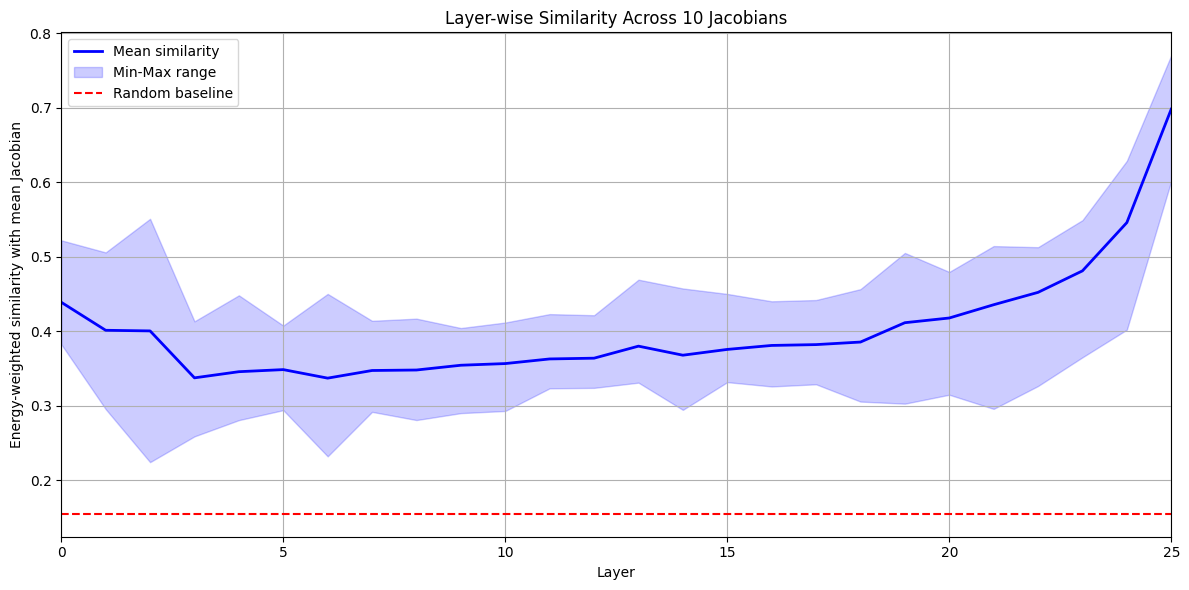

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# sim_array: shape (num_layers, num_jacobians)
num_layers = sim_array.shape[0]

# Compute statistics per layer
# sim_array = (sim_array - S_rand_energy.mean()) / (1-S_rand_energy.mean())
layer_mean = np.mean(sim_array, axis=1)
layer_min = np.min(sim_array, axis=1)
layer_max = np.max(sim_array, axis=1)

# Plot
plt.figure(figsize=(12,6))
plt.plot(range(num_layers), layer_mean, label='Mean similarity', color='blue', linewidth=2)
plt.fill_between(range(num_layers), layer_min, layer_max, color='blue', alpha=0.2, label='Min-Max range')
plt.axhline(y=0.1551, color="r", linestyle="--", label="Random baseline")
plt.xlim(0,25)

plt.xlabel("Layer")
plt.ylabel("Energy-weighted similarity with mean Jacobian")
plt.title("Layer-wise Similarity Across 10 Jacobians")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("jacobian_alignment/" + filename + ".png")
plt.show()


[0.3537708  0.28514799 0.42216172 0.2577607  0.22261841 0.25329062
 0.2187409  0.2663144  0.26411157 0.27355413 0.28250717 0.28519952
 0.28883226 0.28376961 0.28297092 0.30331172 0.31124707 0.30475451
 0.30378835 0.32776189 0.33960052 0.36031489 0.38542205 0.39088405
 0.4299425  0.5567021 ]


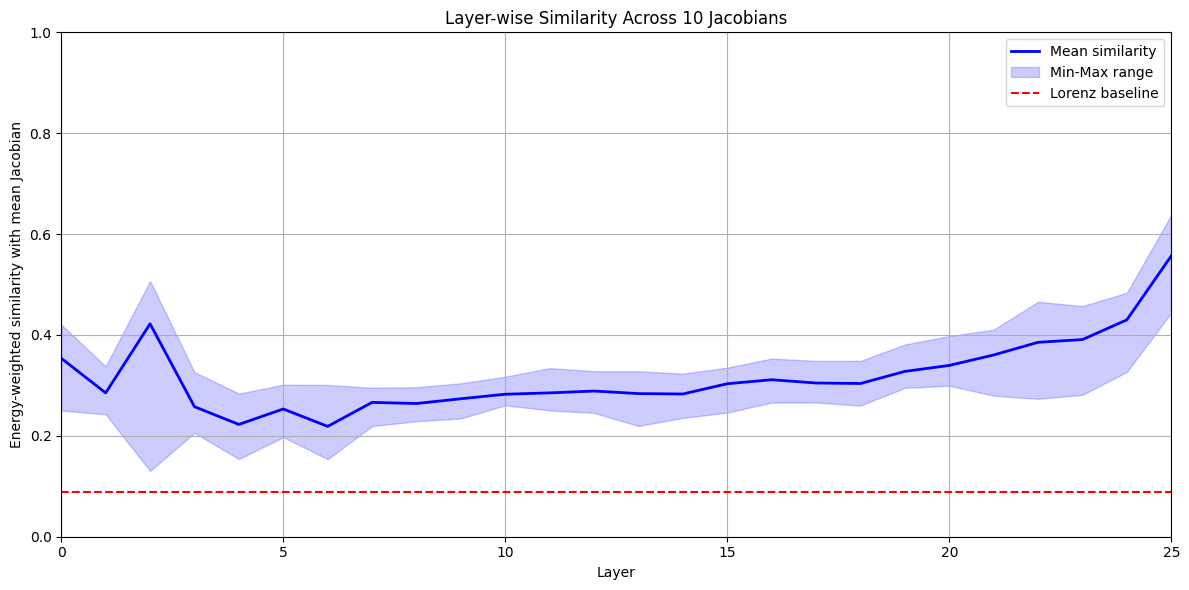

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# sim_array: shape (num_layers, num_jacobians)
num_layers = sim_array.shape[0]

# Compute statistics per layer
sim_array_normed = (sim_array - S_rand_energy.mean()) / (1-S_rand_energy.mean())
layer_mean = np.mean(sim_array_normed, axis=1)
print(layer_mean)
layer_min = np.min(sim_array_normed, axis=1)
layer_max = np.max(sim_array_normed, axis=1)

# Plot
plt.figure(figsize=(12,6))
plt.plot(range(num_layers), layer_mean, label='Mean similarity', color='blue', linewidth=2)
plt.fill_between(range(num_layers), layer_min, layer_max, color='blue', alpha=0.2, label='Min-Max range')

plt.axhline(y=0.08923, color="r", linestyle="--", label="Lorenz baseline")

plt.xlim(0,25)
plt.ylim(0,1)
plt.xlabel("Layer")
plt.ylabel("Energy-weighted similarity with mean Jacobian")
plt.title("Layer-wise Similarity Across 10 Jacobians")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("jacobian_alignment/" + filename + ".png")
plt.show()


In [15]:
# ----------------------------
# Lorenz-96 system
# ----------------------------
from scipy.integrate import solve_ivp
def lorenz96(t, x, F=8.0):
    N = len(x)
    dx = np.zeros_like(x)
    for i in range(N):
        dx[i] = (x[(i+1) % N] - x[i-2]) * x[i-1] - x[i] + F
    return dx


def lorenz96_jacobian(x):
    """
    Analytic Jacobian of Lorenz-96 at state x
    """
    N = len(x)
    J = np.zeros((N, N))

    for i in range(N):
        J[i, i] = -1
        J[i, (i-1) % N] = x[(i+1) % N] - x[i-2]
        J[i, (i+1) % N] = x[i-1]
        J[i, i-2] = -x[i-1]

    return J

N = 500          # dimension (scale this up)
F = 8.0          # chaotic regime
T = 40.0
dt = 0.05

rng = np.random.default_rng(0)
x0 = rng.standard_normal(N)

t_eval = np.arange(0, T, dt)

sol = solve_ivp(
    lorenz96,
    (0, T),
    x0,
    t_eval=t_eval,
    args=(F,),
    rtol=1e-8,
    atol=1e-8
)

trajectory = sol.y.T

Js = np.array([lorenz96_jacobian(x) for x in trajectory])

# Mean Jacobian
J_mean = Js.mean(axis=0)

k = 50  # number of modes (try 20, 50, 100)

def svd_modes(J, k):
    U, s, _ = np.linalg.svd(J, full_matrices=False)
    return U[:, :k], s[:k]

def weighted_cos(angles, wX, wY):
    k = min(len(angles), len(wX), len(wY))
    w = np.sqrt(wX[:k] * wY[:k])
    return np.sum(w * np.cos(angles[:k])) / np.sum(w)

U_m, s_m = svd_modes(J_mean, k)
w_energy = s_m / s_m.sum()

scores = []

for J in Js[::10]:  # subsample to reduce correlation
    U, s = svd_modes(J, k)
    angles = subspace_angles(U_m, U)
    score = weighted_cos(angles, w_energy, w_energy)
    scores.append(score)

scores = np.array(scores)

print(f"Lorenz-96 chaotic baseline:")
print(f"mean similarity = {scores.mean():.3f}")
print(f"std            = {scores.std():.3f}")
print(f"min / max      = {scores.min():.3f} / {scores.max():.3f}")

Lorenz-96 chaotic baseline:
mean similarity = 0.329
std            = 0.034
min / max      = 0.223 / 0.564


In [18]:
n=N
k=k
S_rand_lor = []
for _ in range(num_trials):
    M1 = random_orthonormal(n, k)
    M2 = random_orthonormal(n, k)

    angles = subspace_angles(M1, M2)
    score = weighted_cos(angles, w_energy, w_energy)
    S_rand_lor.append(score)

S_rand_lor = np.array(S_rand_lor)

print(f"Energy-matched ⟨S_rand⟩ = {S_rand_lor.mean():.4f} ± {S_rand_lor.std():.4f}")

print(f"normalized for random chance: {(scores.mean() - S_rand_lor.mean()) / (1-S_rand_lor.mean())}")

Energy-matched ⟨S_rand⟩ = 0.2636 ± 0.0040
normalized for random chance: 0.08923881360705094
